# Train Court Keypoint Detector

---

This notebook is based on the [How to Train YOLOv8 Object Detection on a Custom Dataset](https://github.com/roboflow/notebooks/blob/main/notebooks/train-yolov8-object-detection-on-custom-dataset.ipynb) notebook from the [roboflow/notebooks](https://github.com/roboflow/notebooks) repository.

## Configure API keys

- Open your [`Roboflow Settings`](https://app.roboflow.com/settings/api) page. Click `Copy`. This will place your private key in the clipboard.
- In Colab, go to the left pane and click on `Secrets` (🔑). Store Roboflow API Key under the name `ROBOFLOW_API_KEY`.

## Before you start

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [ ]:
!nvidia-smi

Wed May 20 15:31:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


## Install dependencies

In [ ]:
!pip install -q ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 74.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 95.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 132.3 MB/s eta 0:00:00


## Imports

In [ ]:
from roboflow import Roboflow
from google.colab import userdata
from IPython.display import Image

## Pull dataset

In [ ]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets

ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

project = rf.workspace("roboflow-jvuqo").project("basketball-court-detection-2")
version = project.version(19)
dataset = version.download("yolo26")

#project = rf.workspace("laugekj-b6lqw").project("basketball-court-detection-2-oeojj")
#version = project.version(2)
#dataset = version.download("yolov8")

/content/datasets
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to basketball-court-detection-2-19 in yolo26:: 100%|██████████| 2932/2932 [00:00<00:00, 7017.38it/s]


**NOTE:** Update `data.yaml` structure to align with the latest requirements of the `ultralytics` package.



In [ ]:
!sed -i 's|\(train: \).*|\1../train/images|' {dataset.location}/data.yaml
!sed -i 's|\(val: \).*|\1../valid/images|' {dataset.location}/data.yaml

## Custom training

In [ ]:
%cd {HOME}

!yolo task=pose mode=train model=yolo26s-pose.pt data={dataset.location}/data.yaml batch=32 epochs=100 imgsz=640 plots=True

/content
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/basketball-court-detection-2-19/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=Fal

In [ ]:
!ls {HOME}/runs/pose/train/

args.yaml			 PoseP_curve.png      train_batch3511.jpg
BoxF1_curve.png			 PosePR_curve.png     train_batch3512.jpg
BoxP_curve.png			 PoseR_curve.png      val_batch0_labels.jpg
BoxPR_curve.png			 results.csv	      val_batch0_pred.jpg
BoxR_curve.png			 results.png	      val_batch1_labels.jpg
confusion_matrix_normalized.png  train_batch0.jpg     val_batch1_pred.jpg
confusion_matrix.png		 train_batch1.jpg     weights
labels.jpg			 train_batch2.jpg
PoseF1_curve.png		 train_batch3510.jpg


/content


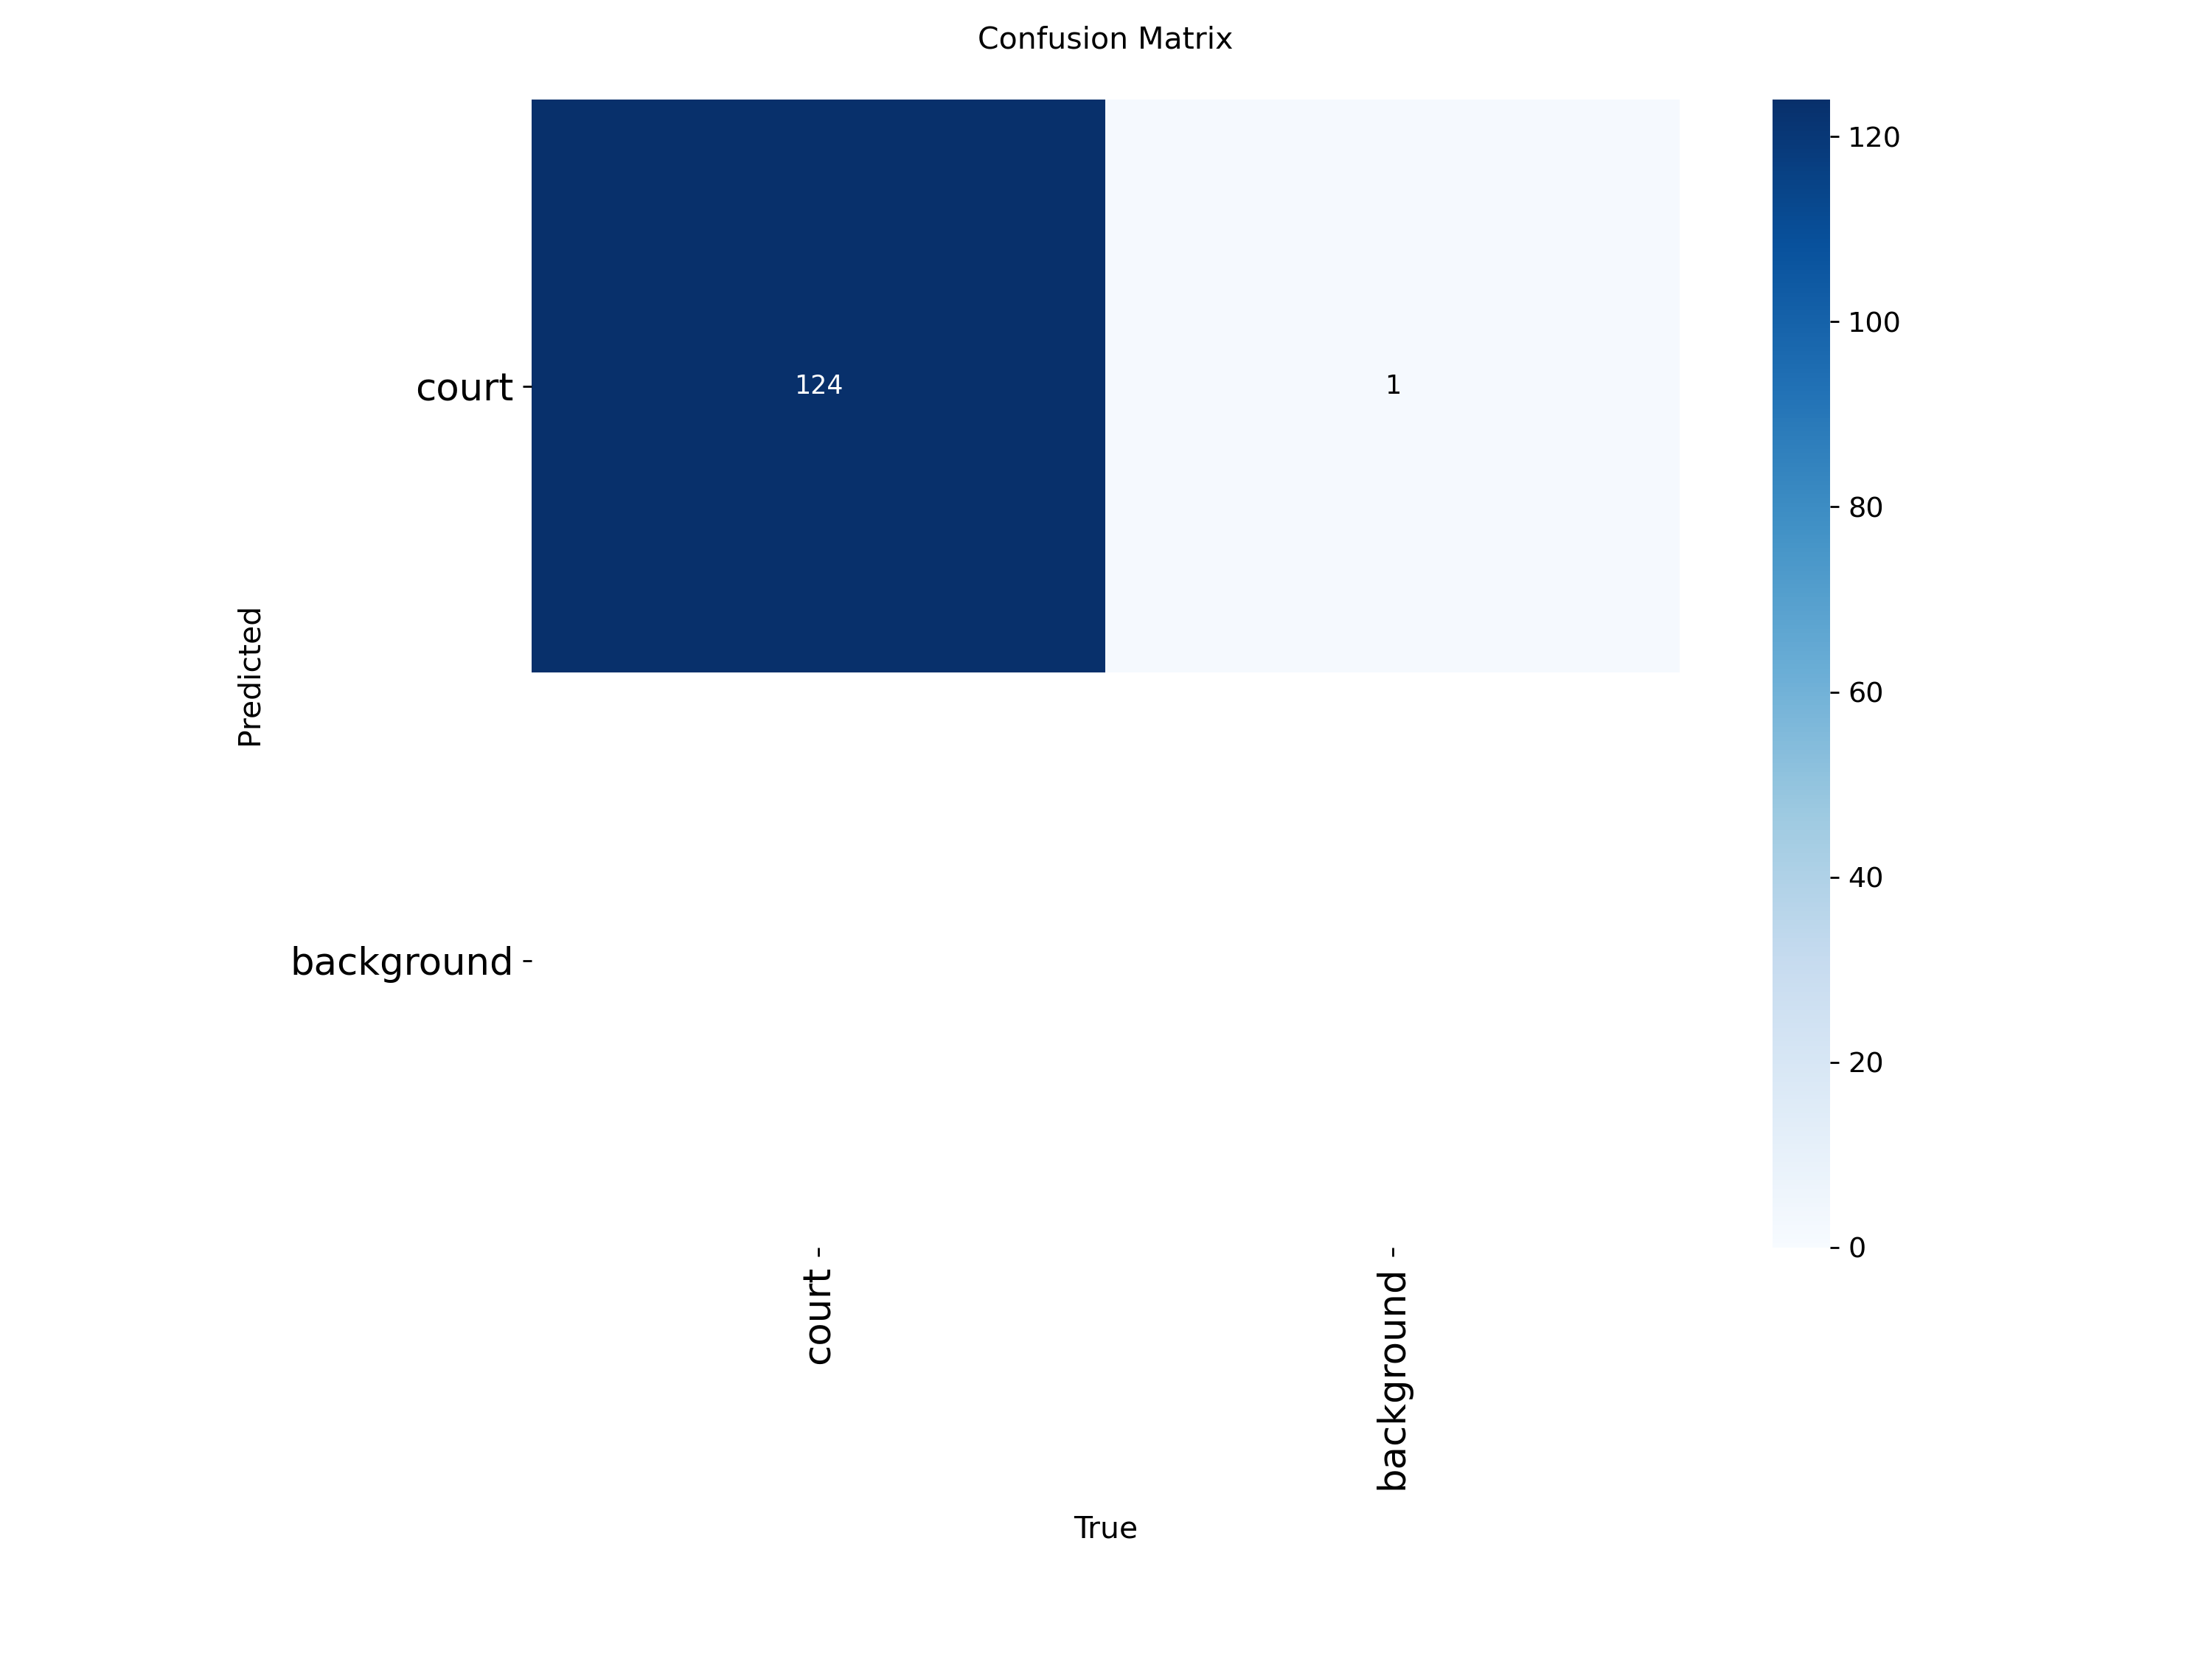

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/pose/train/confusion_matrix.png', width=600)

/content


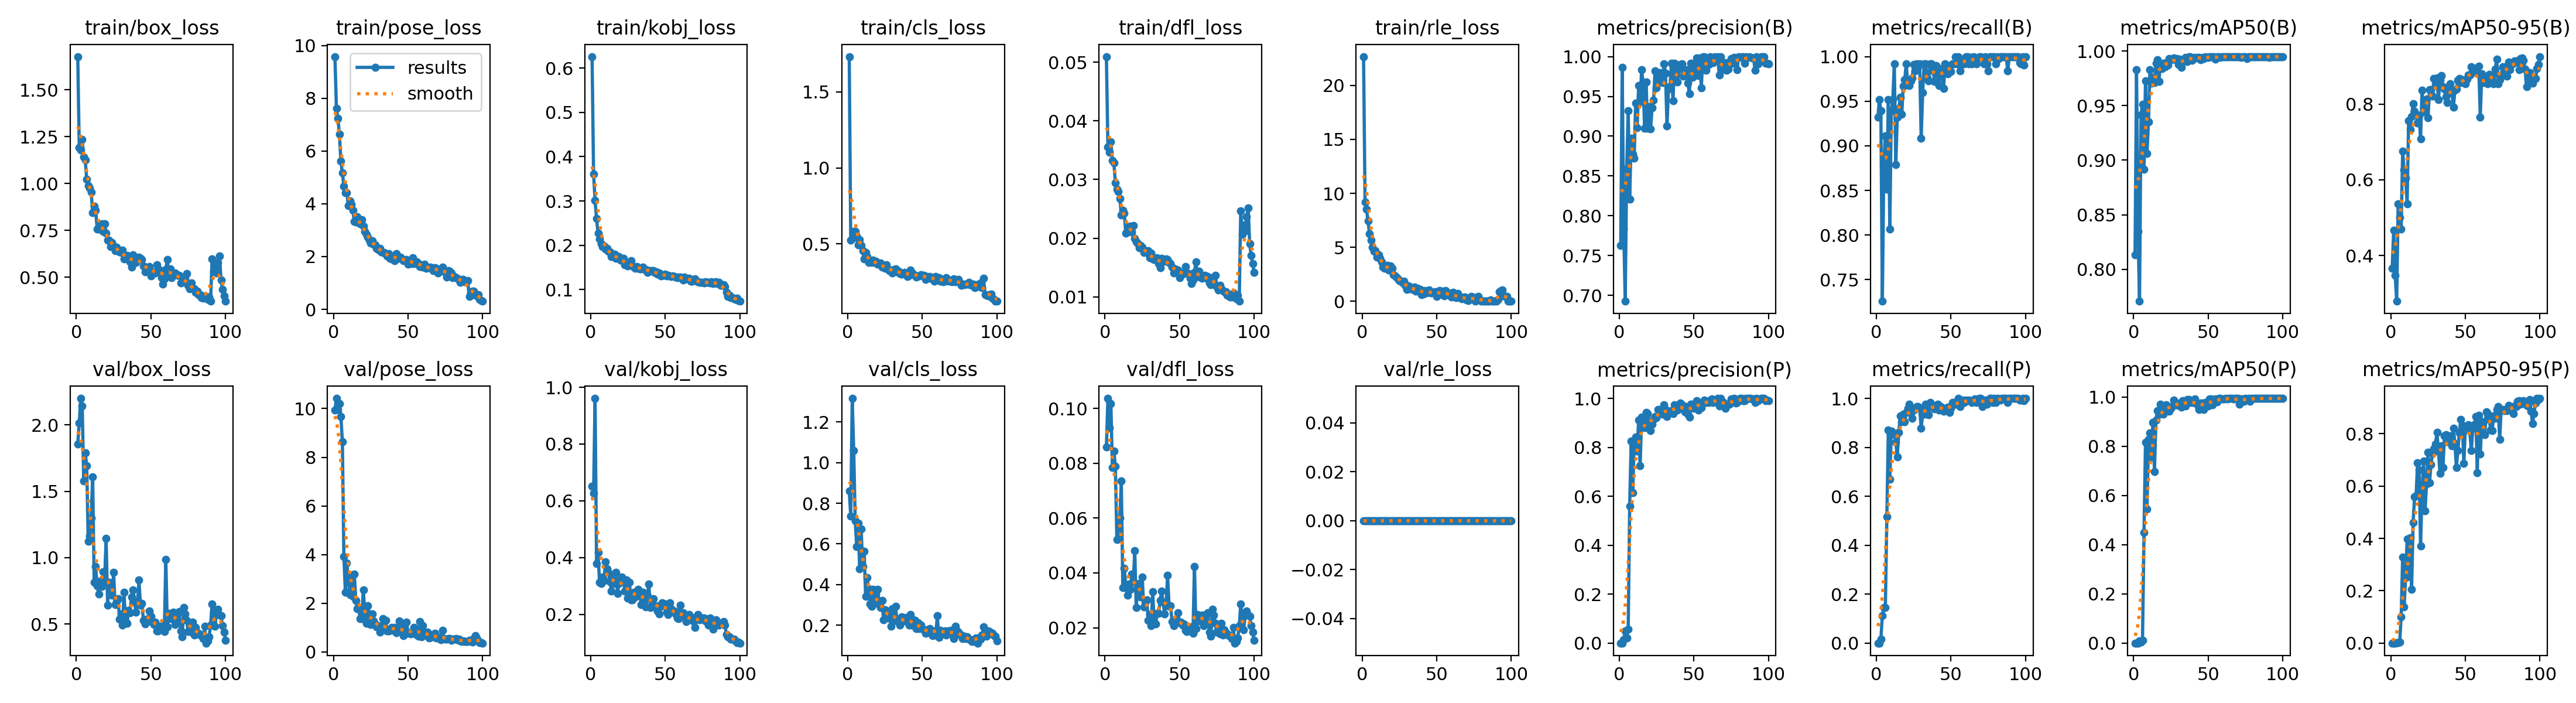

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/pose/train/results.png', width=600)

/content


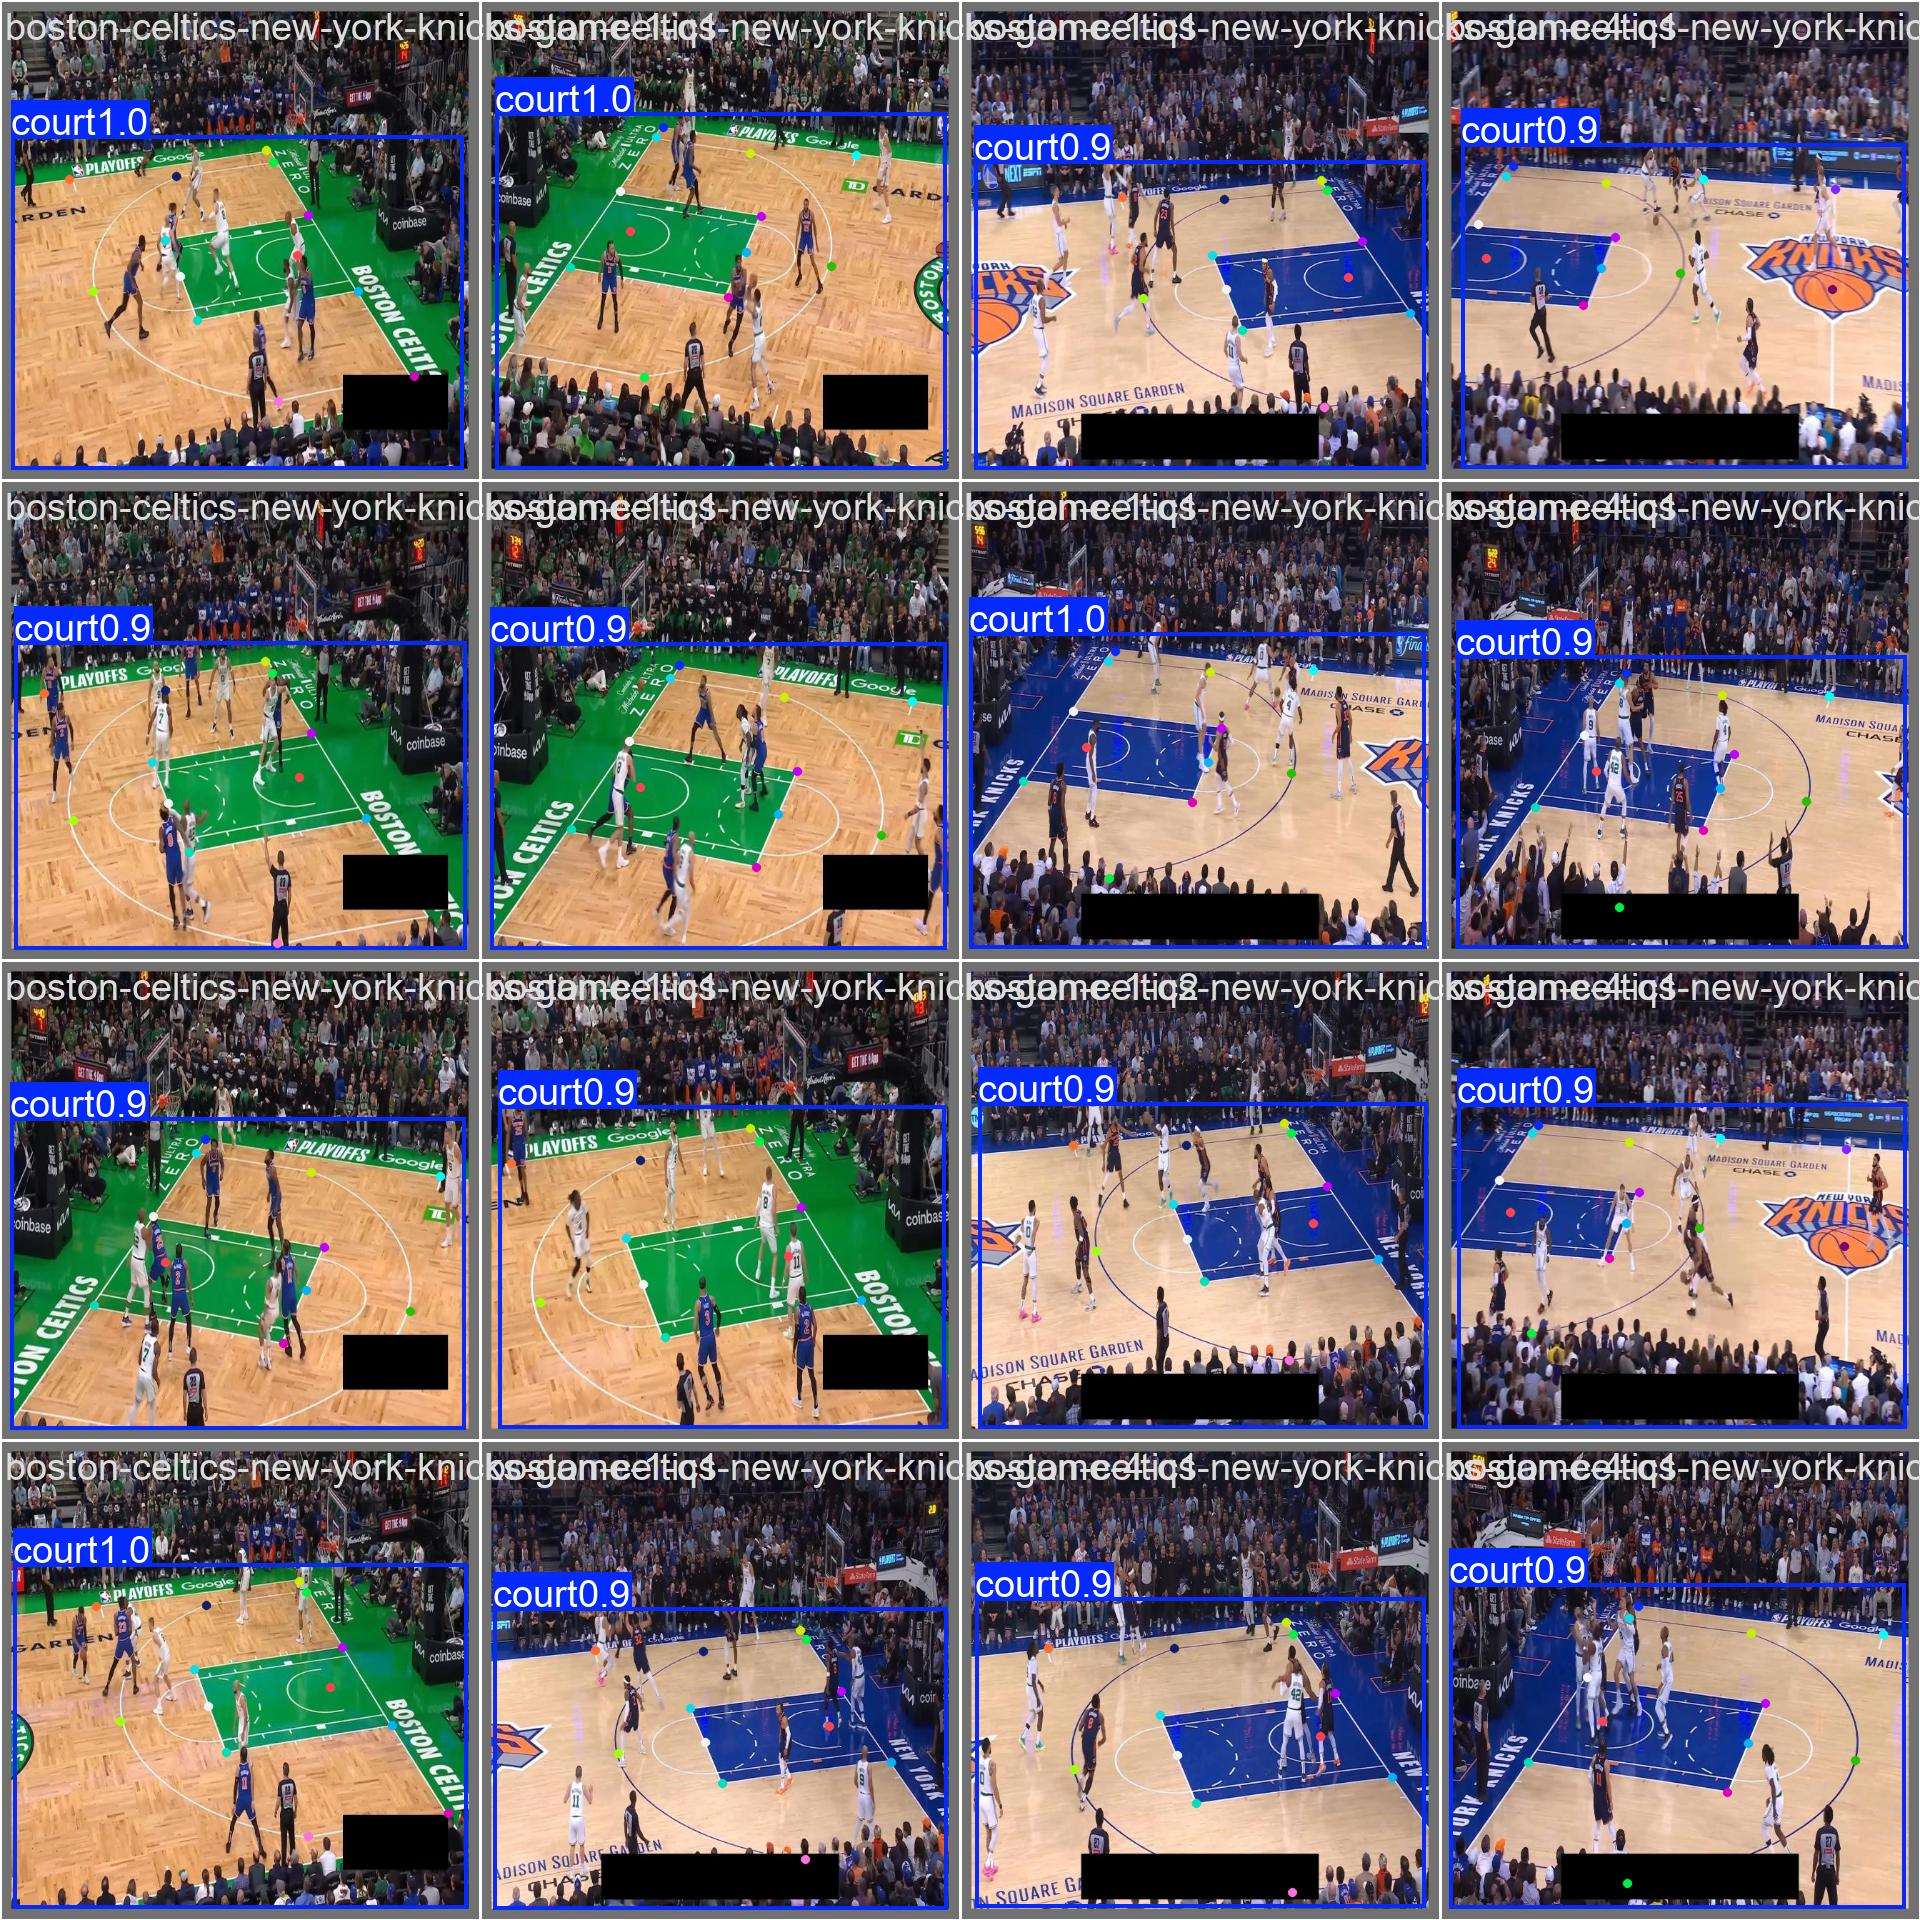

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/pose/train/val_batch0_pred.jpg', width=600)

## Validate custom model

In [ ]:
%cd {HOME}

!yolo task=pose mode=val model={HOME}/runs/pose/train/weights/best.pt data={dataset.location}/data.yaml imgsz=1280

/content
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
YOLO26s-pose summary (fused): 132 layers, 11,581,494 parameters, 0 gradients, 29.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2603.4±533.4 MB/s, size: 87.3 KB)
val: Scanning /content/datasets/basketball-court-detection-2-19/valid/labels.cache... 124 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 124/124 23.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.4it/s 3.4s
                   all        124        124      0.747      0.641       0.59      0.074      0.413      0.492      0.356      0.134
Speed: 6.3ms preprocess, 8.4ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to /content/runs/pose/val
💡 Learn more at https://docs.ultralytics.com/modes/val


In [ ]:
import pandas as pd
from ultralytics import YOLO

In [ ]:
model = YOLO(f"{HOME}/runs/pose/train/weights/best.pt")

metrics = model.val(
    data=f"{dataset.location}/data.yaml",
    imgsz=1280
)

results = {
    "precision": float(metrics.pose.mp),
    "recall": float(metrics.pose.mr),
    "F1": (2 * metrics.pose.mp * metrics.pose.mr) /
           (metrics.pose.mp + metrics.pose.mr + 1e-16),
    "mAP50": float(metrics.pose.map50),
    "mAP50-95": float(metrics.pose.map)
}

df = pd.DataFrame([results])

output_path = f"{HOME}/runs/pose/val/val_metrics.csv"
df.to_csv(output_path, index=False)

print(df)

## (Optional) Save run
Save all files from the model run for thesis.

In [ ]:
FOLDER_NAME = "court-detector-C-yolo26s-run" # Input desired folder name.

In [ ]:
from google.colab import files
import shutil

# create zip
shutil.make_archive(FOLDER_NAME, "zip", f'{HOME}/runs/pose')

# download
files.download(f'{FOLDER_NAME}.zip')

## Export Model to ONNX (for Qualcomm AI Hub)

In [ ]:
!yolo export model="/content/runs/pose/train/weights/best.pt" imgsz=640 format=onnx opset=13


Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO26s-pose summary (fused): 132 layers, 11,581,494 parameters, 0 gradients, 29.2 GFLOPs

PyTorch: starting from '/content/runs/pose/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 105) (27.8 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 215ms
Prepared 4 packages in 1.25s
Installed 4 packages in 280ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime==1.26.0
 + onnxslim==0.1.93

requirements: AutoUpdate success ✅ 2.3s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 13...
/usr/local

In [ ]:
from ultralytics import YOLO

In [ ]:
model = YOLO(f"{HOME}/runs/pose/train/weights/best.pt")

model.export(
    format="onnx",
    imgsz=640,
    opset=13,
    #device="cpu"
    #simplify=True,
    #nms=True
)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
Model summary (fused): 113 layers, 68,133,198 parameters, 0 gradients, 257.4 GFLOPs

PyTorch: starting from '/content/basketball-detector-yolov8x200Epoch.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 14, 8400) (130.4 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 658ms
Prepared 4 packages in 1.85s
Installed 4 packages in 294ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime==1.26.0
 + onnxslim==0.1.93

requirements: AutoUpdate success ✅ 3.4s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 13...
ONNX: slimming with onnxslim 0.1.93...
ONNX: export success ✅ 9.3s, saved as '/content/basketball-detector-yolov8x200Epoch.onnx' (260.2 MB)

Export co

'/content/basketball-detector-yolov8x200Epoch.onnx'

Check model graph to see input and output specs:

In [ ]:
import onnx

model = onnx.load(f"{HOME}/runs/pose/train/weights/best.onnx")

# Completely remove ALL value_info
model.graph.ClearField("value_info")

model_name = f"{HOME}/court-detector-yolo26s100Epoch.onnx" # INPUT DESIRED NAME
onnx.save(model, model_name)

In [ ]:
model = onnx.load(model_name)
onnx.checker.check_model(model)

print("Inputs:")
for tensor in model.graph.input:
    dims = [d.dim_value if d.dim_value > 0 else d.dim_param for d in tensor.type.tensor_type.shape.dim]
    print(f" {tensor.name}: {dims}")

print("Outputs:")
output_shapes = {}
for tensor in model.graph.output:
    dims = [d.dim_value if d.dim_value > 0 else d.dim_param for d in tensor.type.tensor_type.shape.dim]
    output_shapes[tensor.name] = dims
    print(f" {tensor.name}: {dims}")

Inputs:
 images: [1, 3, 640, 640]
Outputs:
 output0: [1, 300, 105]
